# Approximate Bayesian Computation by Subset Simulation (ABC-SS)

This notebook implements a **Bayesian neural network** using the
**Approximate Bayesian Computation + Subset Simulation (ABC-SS)**, pero con
an object-oriented structure inside the `abc_ss` class.

The goal is to preserve the same logic as the original workflow:

1. Initialize a parameter population from a prior.
2. Evaluate each sample using prediction error.
3. Define an acceptance threshold `epsilon` at each level.
4. Propagate mutation chains from accepted seeds.
5. Keep a population conditioned on progressively smaller errors.


In [10]:
from __future__ import annotations

import math
import time
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

np.random.seed(7)
start_time = time.time()

## 1. Core functions

We define activation functions and an MSE error metric to evaluate each
network parameter sample.

In [11]:
def relu_derivative(values: np.ndarray) -> np.ndarray:
    grad = values.copy()
    grad[grad <= 0] = 0
    grad[grad > 0] = 1
    return grad


sigmoid = (
    lambda z: 1.0 / (1.0 + np.exp(-z)),
    lambda y: y * (1.0 - y),
)

tanh = (
    lambda z: np.tanh(z),
    lambda z: 1.0 - np.tanh(z) ** 2,
)

relu = (
    lambda z: z * (z > 0),
    lambda z: relu_derivative(z),
)


def mse_metric(prediction: np.ndarray, target: np.ndarray) -> float:
    return float(np.mean((np.asarray(prediction) - np.asarray(target)) ** 2))

## 2. `abc_ss` class

This class encapsulates the full ABC-SS engine:

- Parameter packing and unpacking (`theta -> W, b`).
- Network forward pass.
- Population initialization from a truncated prior.
- SubSim level loop with seeds and mutations.
- Storage of error history, epsilons, and acceptance rates.
- Point prediction and posterior ensemble summary.

In [12]:
@dataclass
class ABCSSConfig:
    layer_sizes: list[int]
    activations: list[tuple]
    n_samples: int = 500
    p0: float = 0.10
    sim_levels: int = 8
    proposal_std: float = 0.15
    std_decay: float = 0.90
    prior_low: float = -1.0
    prior_high: float = 1.0


class abc_ss:
    def __init__(self, cfg: ABCSSConfig):
        self.cfg = cfg
        if len(cfg.layer_sizes) - 1 != len(cfg.activations):
            raise ValueError("The number of activations must match the number of layers.")
        if not (0.0 < cfg.p0 < 1.0):
            raise ValueError("p0 must be in the range (0, 1).")

        self.weight_sizes = []
        self.bias_sizes = []
        self.n_weights = 0
        self.n_bias = 0

        for in_dim, out_dim in zip(cfg.layer_sizes[:-1], cfg.layer_sizes[1:]):
            w_count = in_dim * out_dim
            b_count = out_dim
            self.weight_sizes.append((in_dim, out_dim, w_count))
            self.bias_sizes.append((out_dim, b_count))
            self.n_weights += w_count
            self.n_bias += b_count

        self.theta_dim = self.n_weights + self.n_bias
        self.seed_count = int(math.ceil(cfg.p0 * cfg.n_samples))
        self.seed_count = max(1, min(self.seed_count, cfg.n_samples - 1))

        self.population_history = []
        self.epsilon_history = []
        self.acceptance_rate_history = []

        self.population_ = None
        self.ranked_population_ = None
        self.best_theta_ = None
        self.best_error_ = None

    def _make_colnames(self) -> list[str]:
        colnames = []
        for level_idx, (in_dim, out_dim, _) in enumerate(self.weight_sizes):
            for i in range(in_dim):
                for j in range(out_dim):
                    colnames.append(f"W{level_idx}_{i}_{j}")
        for level_idx, (out_dim, _) in enumerate(self.bias_sizes):
            for j in range(out_dim):
                colnames.append(f"b{level_idx + 1}_{j}")
        colnames.append("Error")
        return colnames

    def _split_theta(self, theta: np.ndarray) -> tuple[list[np.ndarray], list[np.ndarray]]:
        ref = 0
        weights = []
        for in_dim, out_dim, w_count in self.weight_sizes:
            w_flat = theta[ref : ref + w_count]
            weights.append(w_flat.reshape(in_dim, out_dim))
            ref += w_count

        biases = []
        for out_dim, b_count in self.bias_sizes:
            b_flat = theta[ref : ref + b_count]
            biases.append(b_flat.reshape(1, out_dim))
            ref += b_count

        return weights, biases

    def _forward(self, x_data: np.ndarray, theta: np.ndarray) -> np.ndarray:
        w_list, b_list = self._split_theta(theta)
        out = x_data
        for layer_idx in range(len(w_list)):
            z_layer = out @ w_list[layer_idx] + b_list[layer_idx]
            out = self.cfg.activations[layer_idx][0](z_layer)
        return out

    def _sample_prior_population(self) -> np.ndarray:
        pop = np.zeros((self.cfg.n_samples, self.theta_dim + 1), dtype=np.float64)
        low, high = self.cfg.prior_low, self.cfg.prior_high
        for col_idx in range(self.theta_dim):
            pop[:, col_idx] = stats.truncnorm.rvs(low, high, loc=0.0, scale=1.0, size=self.cfg.n_samples)
        return pop

    def _evaluate_population(self, pop: np.ndarray, x_data: np.ndarray, y_data: np.ndarray) -> None:
        for i in range(pop.shape[0]):
            theta = pop[i, : self.theta_dim]
            pred = self._forward(x_data, theta)
            pop[i, -1] = mse_metric(pred, y_data)

    def _rank_population(self, pop: np.ndarray) -> np.ndarray:
        return pop[pop[:, -1].argsort()]

    def _children_per_seed(self) -> list[int]:
        required = self.cfg.n_samples - self.seed_count
        base = required // self.seed_count
        rem = required % self.seed_count
        children = [base] * self.seed_count
        for i in range(rem):
            children[i] += 1
        return children

    def fit(self, x_data: np.ndarray, y_data: np.ndarray) -> "abc_ss":
        x_data = np.asarray(x_data, dtype=np.float64)
        y_data = np.asarray(y_data, dtype=np.float64)

        # Level 0: prior + evaluation
        population = self._sample_prior_population()
        self._evaluate_population(population, x_data, y_data)
        self.population_history = [population.copy()]
        self.epsilon_history = []
        self.acceptance_rate_history = []

        children_plan = self._children_per_seed()

        # SubSim levels
        for level in range(self.cfg.sim_levels):
            ranked = self._rank_population(population)
            epsilon = ranked[self.seed_count - 1, -1]
            seeds = ranked[: self.seed_count, :].copy()

            std_now = self.cfg.proposal_std * (self.cfg.std_decay**level)
            offspring = np.zeros((self.cfg.n_samples - self.seed_count, self.theta_dim + 1), dtype=np.float64)

            out_row = 0
            accepted_moves = 0
            attempted_moves = 0

            for seed_idx in range(self.seed_count):
                prev_theta = seeds[seed_idx, : self.theta_dim].copy()
                prev_error = float(seeds[seed_idx, -1])

                n_children = children_plan[seed_idx]
                for _ in range(n_children):
                    attempted_moves += 1
                    proposal_theta = prev_theta + np.random.normal(0.0, std_now, size=self.theta_dim)
                    proposal_pred = self._forward(x_data, proposal_theta)
                    proposal_error = mse_metric(proposal_pred, y_data)

                    # SubSim rule: keep the chain inside the accepted region
                    if proposal_error <= epsilon:
                        prev_theta = proposal_theta
                        prev_error = proposal_error
                        accepted_moves += 1

                    offspring[out_row, : self.theta_dim] = prev_theta
                    offspring[out_row, -1] = prev_error
                    out_row += 1

            population = np.concatenate((seeds, offspring), axis=0)
            self.population_history.append(population.copy())
            self.epsilon_history.append(float(epsilon))
            self.acceptance_rate_history.append(float(accepted_moves / max(1, attempted_moves)))

        self.population_ = population
        self.ranked_population_ = self._rank_population(population)
        self.best_theta_ = self.ranked_population_[0, : self.theta_dim].copy()
        self.best_error_ = float(self.ranked_population_[0, -1])
        return self

    def predict(self, x_data: np.ndarray, theta: np.ndarray | None = None) -> np.ndarray:
        if theta is None:
            if self.best_theta_ is None:
                raise RuntimeError("You must run fit() before predicting.")
            theta = self.best_theta_
        return self._forward(np.asarray(x_data, dtype=np.float64), np.asarray(theta, dtype=np.float64))

    def predict_ensemble(self, x_data: np.ndarray, top_k: int = 50) -> np.ndarray:
        if self.ranked_population_ is None:
            raise RuntimeError("You must run fit() before using predict_ensemble().")

        top_k = max(1, min(top_k, self.ranked_population_.shape[0]))
        x_data = np.asarray(x_data, dtype=np.float64)
        y_matrix = np.zeros((x_data.shape[0], top_k), dtype=np.float64)

        for i in range(top_k):
            theta_i = self.ranked_population_[i, : self.theta_dim]
            y_matrix[:, i : i + 1] = self._forward(x_data, theta_i)

        return y_matrix

    def plot_error_hist(self, errors: np.ndarray, epsilons: list[float], level: int | None = None) -> None:
        plt.figure(figsize=(9, 5))
        sns.histplot(errors, bins=35, color="lightgray", edgecolor="black", kde=False)

        for i, eps in enumerate(epsilons):
            plt.axvline(eps, linestyle="--", linewidth=2, label=f"epsilon[{i}] = {eps:.5f}")

        if len(epsilons) > 0:
            rejected = int(np.sum(errors > epsilons[-1]))
            plt.text(0.03, 0.93, f"Rejected: {rejected}", transform=plt.gca().transAxes)

        title = "Error distribution"
        if level is not None:
            title += f" - Level {level}"
        plt.title(title)
        plt.xlabel("MSE")
        plt.ylabel("Frequency")
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_error_hist_all(self, all_errors: list[np.ndarray], epsilons: list[float]) -> None:
        plt.figure(figsize=(10, 5))
        colors = sns.color_palette("tab10", n_colors=max(1, len(all_errors)))

        for idx, errors in enumerate(all_errors):
            sns.kdeplot(errors, fill=False, linewidth=2, color=colors[idx], label=f"Level {idx}")

        for i, eps in enumerate(epsilons):
            plt.axvline(eps, linestyle="--", linewidth=2, alpha=0.9, label=f"epsilon[{i}] = {eps:.5f}")

        plt.title("Cumulative error evolution by level")
        plt.xlabel("MSE")
        plt.ylabel("Density")
        plt.legend(ncol=2)
        plt.tight_layout()
        plt.show()

## 3. Dataset generation

We keep the original cosine regression experiment:

- `X`: 400 points in `[-3, 3]`
- `Y`: `cos(X)` + small Gaussian noise

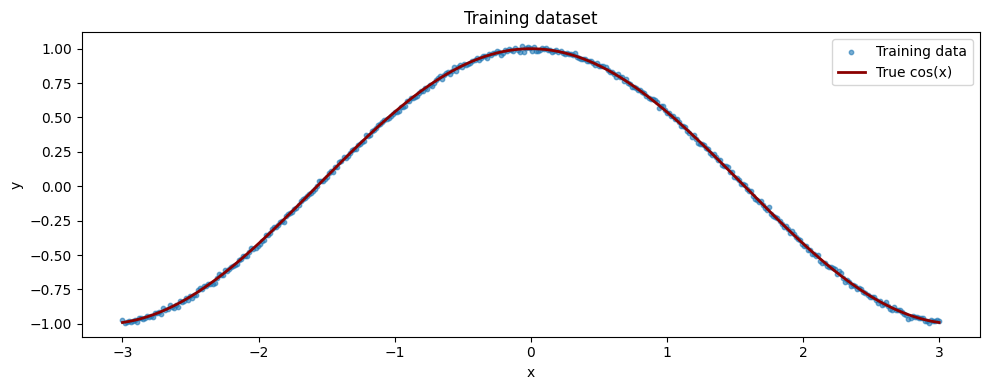

In [13]:
n_inputs = 400
x_train = np.linspace(-3.0, 3.0, num=n_inputs)
y_train = np.cos(x_train) + np.random.normal(0.0, 0.01, size=n_inputs)

x_train = x_train.astype(np.float64).reshape((n_inputs, 1))
y_train = y_train.astype(np.float64).reshape((n_inputs, 1))

plt.figure(figsize=(10, 4))
plt.scatter(x_train, y_train, s=10, alpha=0.6, label="Training data")
plt.plot(x_train, np.cos(x_train), color="darkred", linewidth=2, label="True cos(x)")
plt.title("Training dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

## 4. ABC-SS setup and training

The network keeps the same conceptual architecture as the previous notebook
(`1-5-5-1` with `tanh` activations) and applies SubSim levels.

In [14]:
config = ABCSSConfig(
    layer_sizes=[1, 5, 5, 1],
    activations=[tanh, tanh, tanh],
    n_samples=500,
    p0=0.10,
    sim_levels=8,
    proposal_std=0.15,
    std_decay=0.90,
    prior_low=-1.0,
    prior_high=1.0,
)

model = abc_ss(config)
model.fit(x_train, y_train)

print(f"Parameter dimension: {model.theta_dim}")
print(f"Number of seeds per level: {model.seed_count}")
print(f"Best final error (MSE): {model.best_error_:.8f}")
print(f"Epsilons by level: {np.round(model.epsilon_history, 8)}")
print(f"Acceptance rate by level: {np.round(model.acceptance_rate_history, 4)}")

Parameter dimension: 46
Number of seeds per level: 50
Best final error (MSE): 0.00512821
Epsilons by level: [0.51449407 0.3150567  0.16535054 0.07383507 0.03187422 0.01753129
 0.00816524 0.00816524]
Acceptance rate by level: [0.5    0.3844 0.2733 0.22   0.12   0.0533 0.0067 0.0111]


## 5. Error analysis by level

We visualize error distributions by level and the cumulative evolution
of the `epsilon` thresholds.

/tmp/ipykernel_140398/2236433557.py:205: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


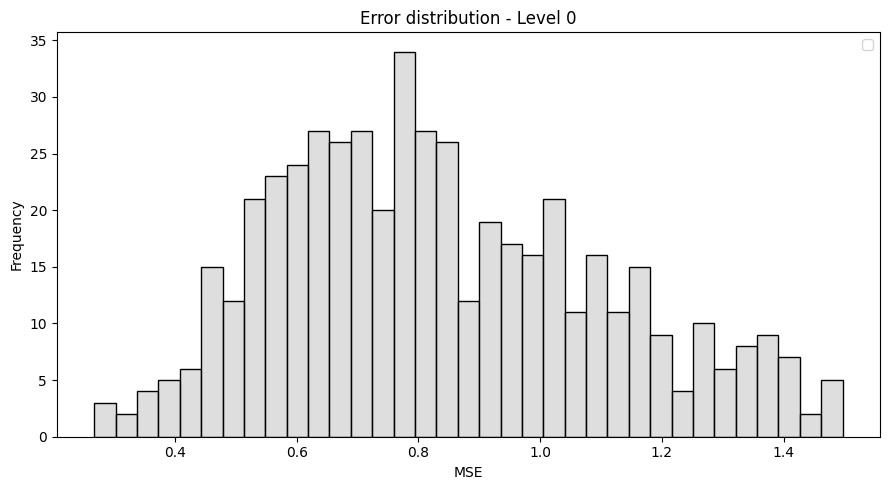

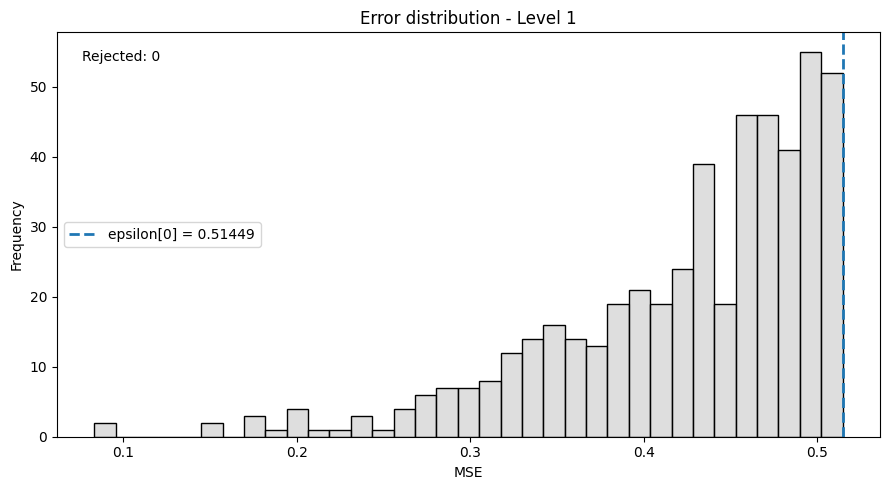

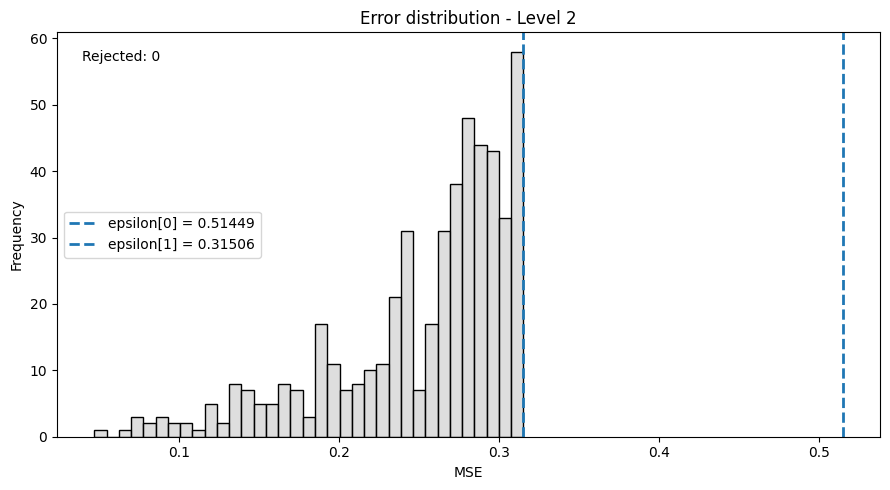

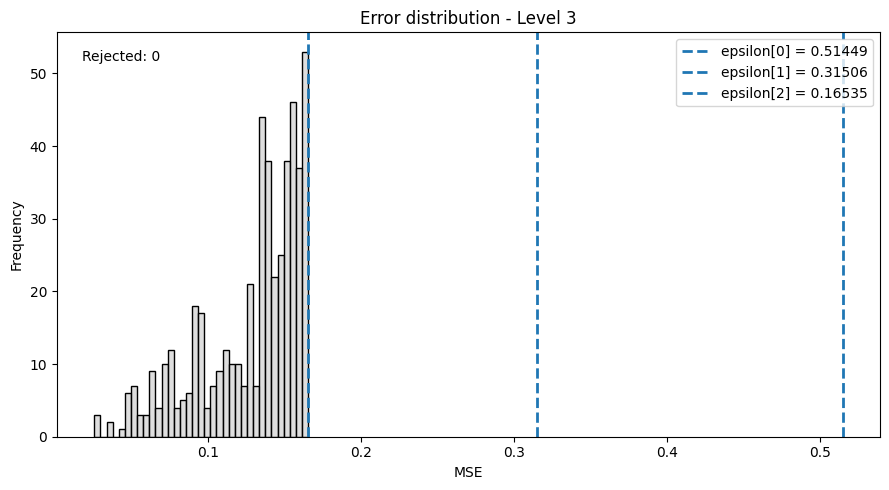

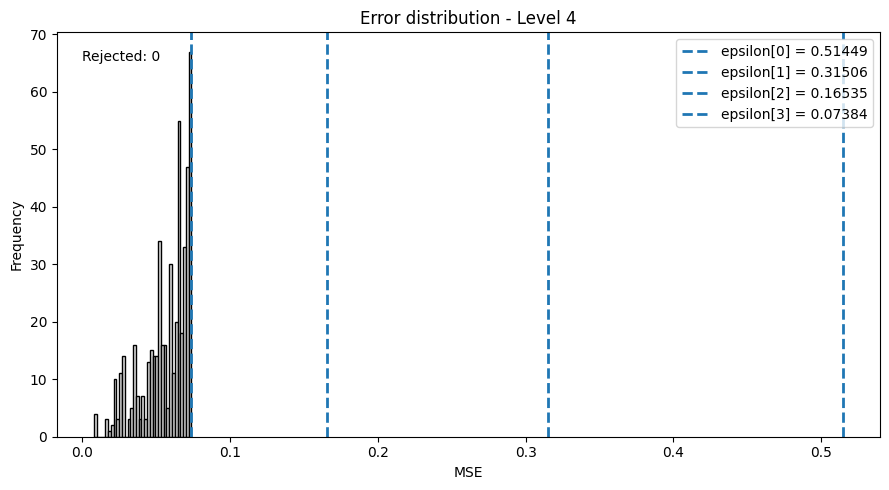

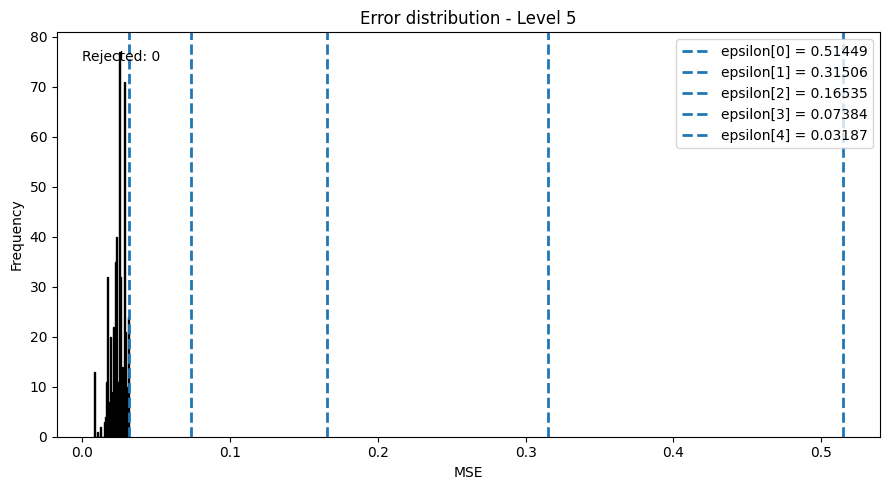

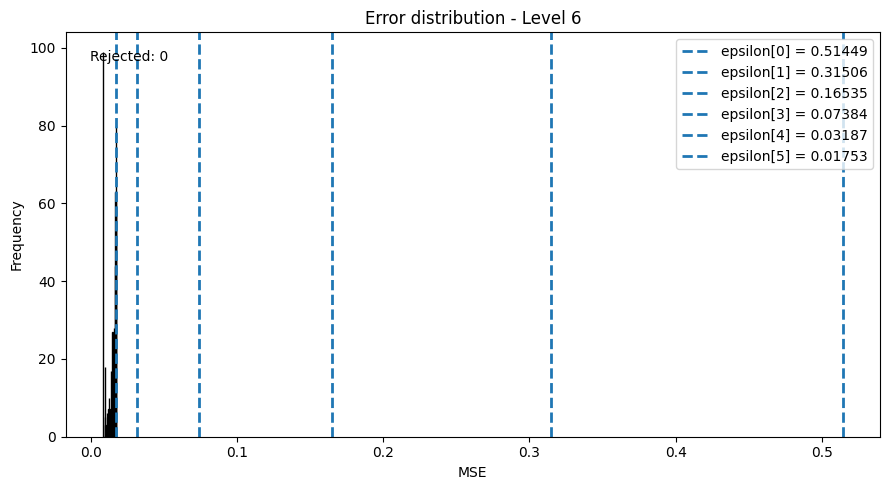

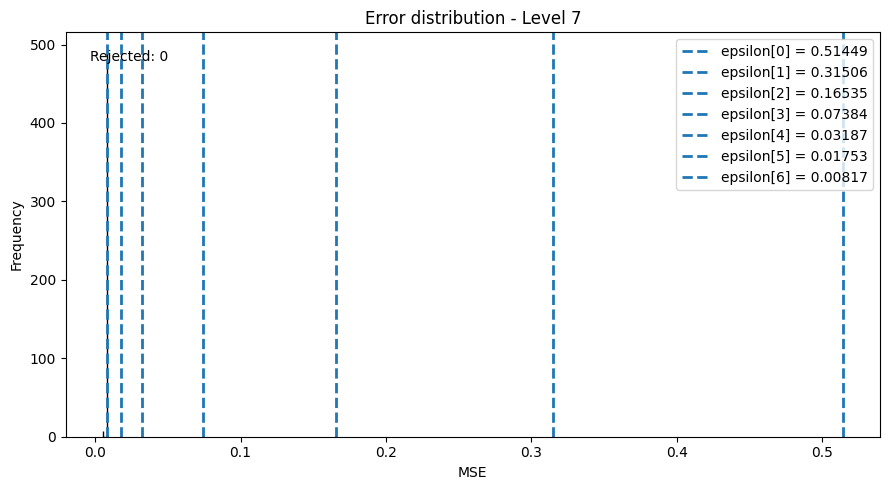

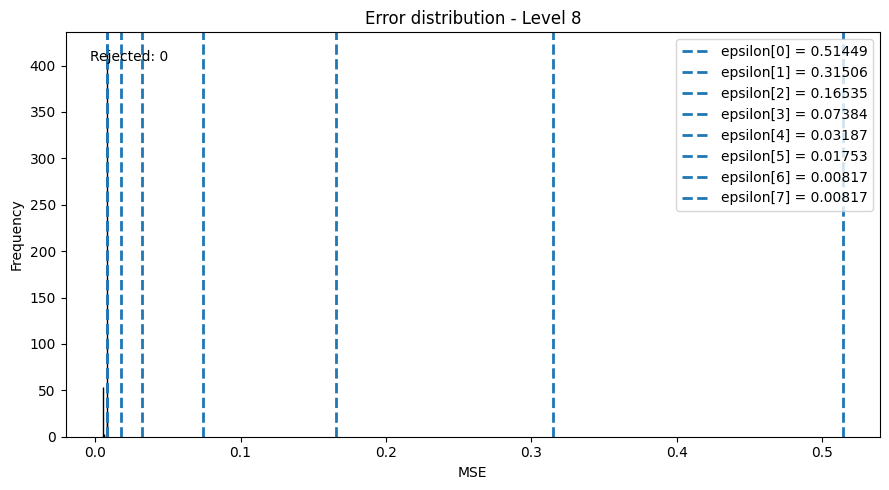

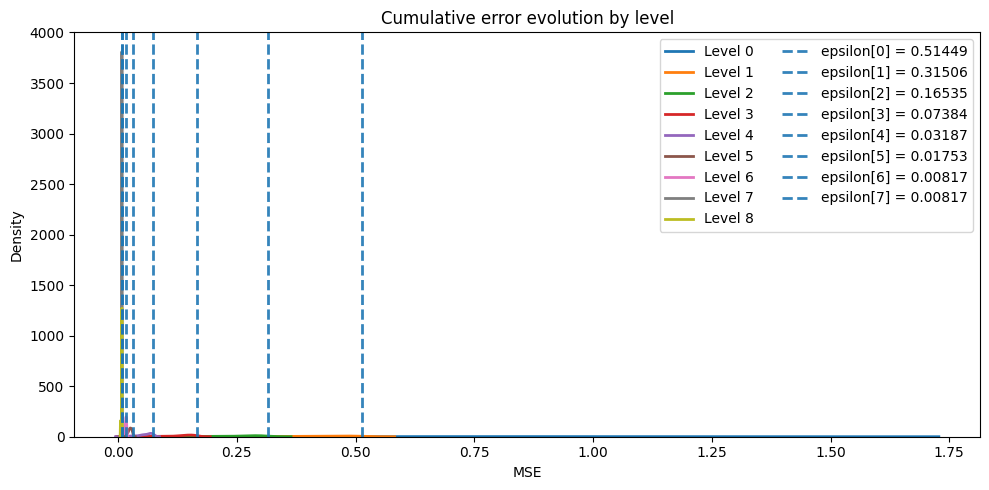

In [15]:
for lvl in range(len(model.population_history)):
    errors_lvl = model.population_history[lvl][:, -1]
    eps_lvl = model.epsilon_history[:lvl] if lvl > 0 else []
    model.plot_error_hist(errors_lvl, eps_lvl, level=lvl)

all_level_errors = [pop[:, -1] for pop in model.population_history]
model.plot_error_hist_all(all_level_errors, model.epsilon_history)

## 6. Best final model

We take the best final `theta` (lowest MSE) and compare it against the dataset.

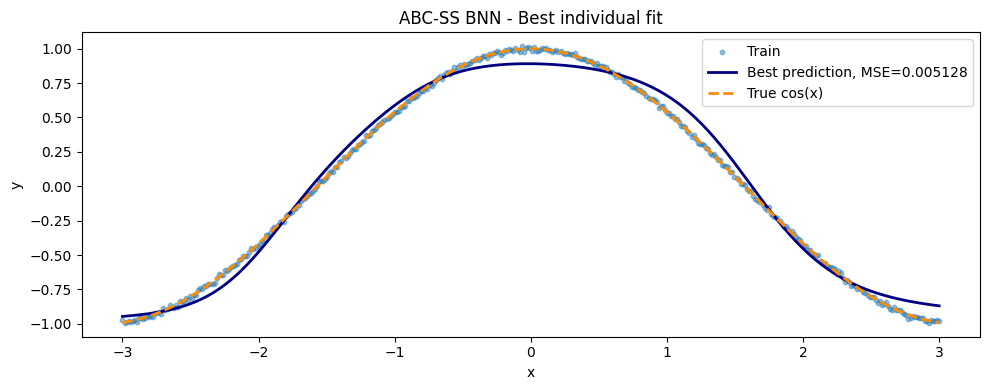

In [16]:
y_pred_train_best = model.predict(x_train)
err_train_best = mse_metric(y_pred_train_best, y_train)

plt.figure(figsize=(10, 4))
plt.scatter(x_train, y_train, s=10, alpha=0.45, label="Train")
plt.plot(x_train, y_pred_train_best, color="navy", linewidth=2, label=f"Best prediction, MSE={err_train_best:.6f}")
plt.plot(x_train, np.cos(x_train), color="darkorange", linewidth=2, linestyle="--", label="True cos(x)")
plt.title("ABC-SS BNN - Best individual fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Test evaluation and uncertainty band

We take several accepted samples from the approximate posterior (top-k) to obtain:

- predictive mean
- 2.5% and 97.5% percentiles (95% confidence interval)
- coverage of real points inside the band

MSE test (best): 0.00506500
MSE test (mean posterior): 0.00480386
Coverage in 95% CI [2.5%,97.5%]: 26.75%


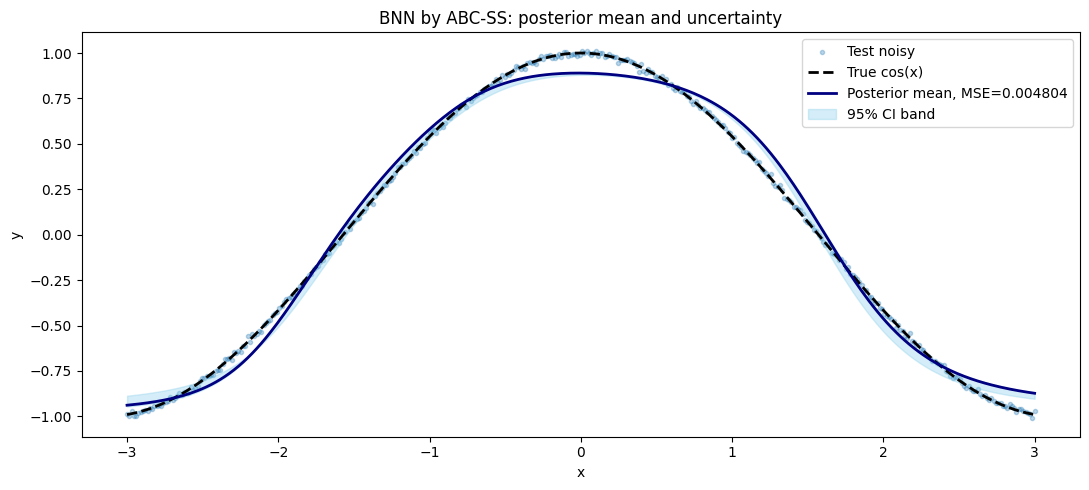

In [17]:
x_test = np.linspace(-3.0, 3.0, num=n_inputs).astype(np.float64).reshape((n_inputs, 1))
y_test = (np.cos(x_test) + np.random.normal(0.0, 0.01, size=(n_inputs, 1))).astype(np.float64)

y_pred_test_best = model.predict(x_test)
err_test_best = mse_metric(y_pred_test_best, y_test)

top_k = 50
y_matrix = model.predict_ensemble(x_test, top_k=top_k)
y_mean = np.mean(y_matrix, axis=1, keepdims=True)
y_p025 = np.percentile(y_matrix, 2.5, axis=1, keepdims=True)
y_p975 = np.percentile(y_matrix, 97.5, axis=1, keepdims=True)
err_mean = mse_metric(y_mean, y_test)

inside_band = np.logical_and(y_test >= y_p025, y_test <= y_p975)
coverage = 100.0 * float(np.mean(inside_band))

print(f"MSE test (best): {err_test_best:.8f}")
print(f"MSE test (mean posterior): {err_mean:.8f}")
print(f"Coverage in 95% CI [2.5%,97.5%]: {coverage:.2f}%")

order = np.argsort(x_test[:, 0])
x_plot = x_test[order, 0]
y_test_plot = y_test[order, 0]
y_mean_plot = y_mean[order, 0]
y_p025_plot = y_p025[order, 0]
y_p975_plot = y_p975[order, 0]

plt.figure(figsize=(11, 5))
plt.scatter(x_plot, y_test_plot, s=9, alpha=0.30, label="Test noisy")
plt.plot(x_plot, np.cos(x_plot), color="black", linewidth=2, linestyle="--", label="True cos(x)")
plt.plot(x_plot, y_mean_plot, color="navy", linewidth=2, label=f"Posterior mean, MSE={err_mean:.6f}")
plt.fill_between(x_plot, y_p025_plot, y_p975_plot, color="skyblue", alpha=0.35, label="95% CI band")
plt.title("BNN by ABC-SS: posterior mean and uncertainty")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Posterior distribution of one parameter

Simple inspection of one `theta` parameter in the final ranked population.

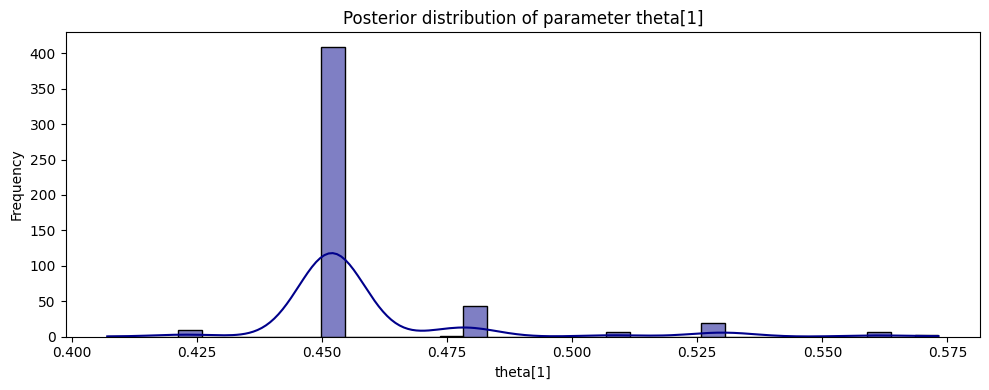

Total time (s): 2.488


In [18]:
param_index = 1
n_bins = 35

plt.figure(figsize=(10, 4))
sns.histplot(model.ranked_population_[:, param_index], bins=n_bins, kde=True, color="darkblue", edgecolor="black")
plt.title(f"Posterior distribution of parameter theta[{param_index}]")
plt.xlabel(f"theta[{param_index}]")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

end_time = time.time()
print(f"Total time (s): {end_time - start_time:.3f}")